# Task 2: Feature Engineering, Model Optimization & Performance Comparison
**Dataset:** California Housing Dataset (scikit-learn)  
**Goal:** Apply feature scaling, train multiple models, and compare their performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 1: Data Exploration

In [4]:
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

=== Statistical Summary ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.84615

## Step 2: Separate Features and Target Variable

In [5]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


## Step 3: Feature Scaling
Applying StandardScaler so all features are on the same scale.  
Without scaling, features with larger ranges dominate the model.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Before Scaling (first row):")
print(X.iloc[0].values)
print("\nAfter Scaling (first row):")
print(X_scaled_df.iloc[0].values)

Before Scaling (first row):
[   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]

After Scaling (first row):
[ 2.34476576  0.98214266  0.62855945 -0.15375759 -0.9744286  -0.04959654
  1.05254828 -1.32783522]


## Step 4: Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 16512
Testing samples:  4128


## Step 5: Train Multiple Models
Training 3 models:
- **Linear Regression** — baseline model
- **Ridge Regression** — reduces overfitting using regularization
- **Decision Tree** — captures non-linear relationships

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

## Step 6: Evaluate and Compare All Models

In [9]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae  = mean_absolute_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2   = r2_score(y_test, predictions)

    results[name] = {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                      MAE    RMSE  R2 Score
Linear Regression  0.5332  0.7456    0.5758
Ridge Regression   0.5332  0.7456    0.5758
Decision Tree      0.5223  0.7242    0.5997


## Step 7: Model Comparison Table

In [10]:
results_df.style.highlight_min(color='lightgreen', axis=0, subset=['MAE', 'RMSE']) \
               .highlight_max(color='lightgreen', axis=0, subset=['R2 Score'])

,MAE,RMSE,R2 Score
Linear Regression,0.533200,0.745600,0.575800
Ridge Regression,0.533200,0.745600,0.575800
Decision Tree,0.522300,0.724200,0.599700


## Step 8: Visual Performance Comparison

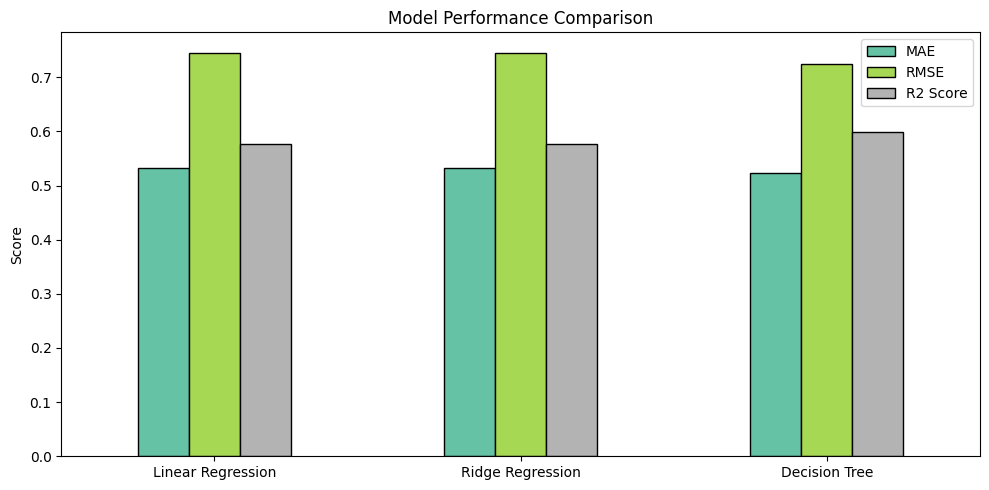

In [11]:
results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

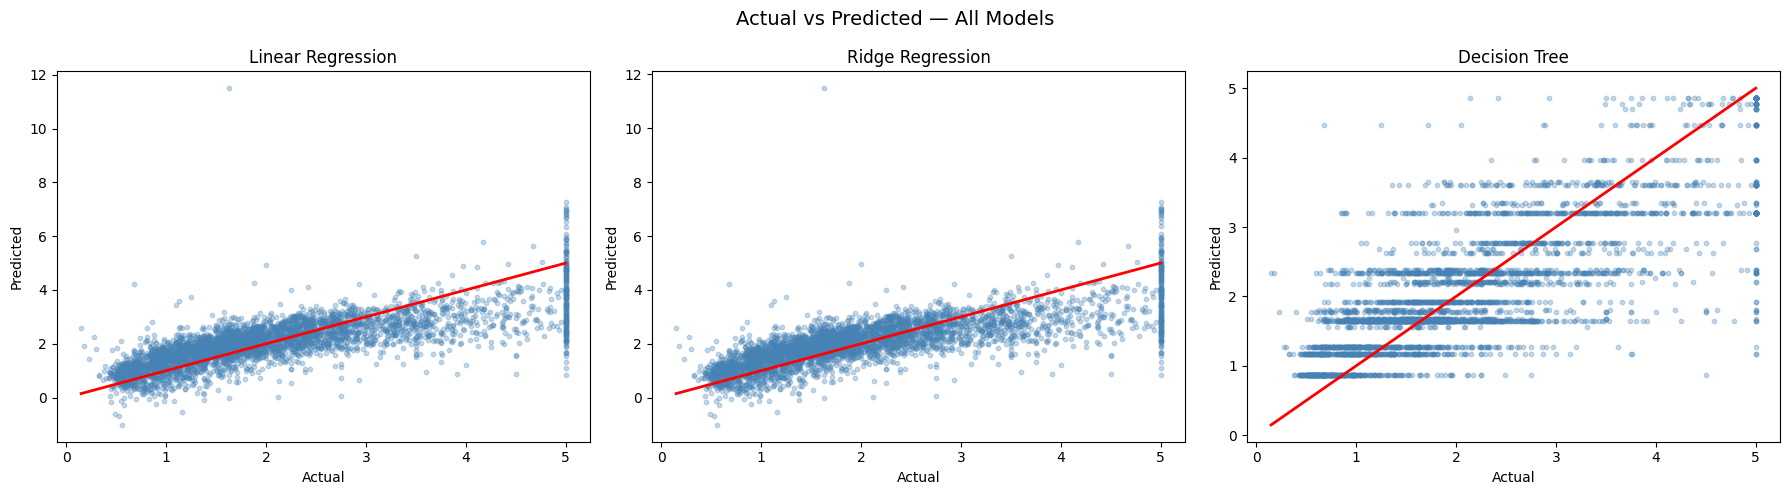

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    ax.scatter(y_test, preds, alpha=0.3, s=10, color='steelblue')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linewidth=2)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('actual_vs_predicted_all.png')
plt.show()

## Step 9: Best Model Selection & Justification

In [13]:
best_model_name = results_df['R2 Score'].idxmax()
best_r2 = results_df.loc[best_model_name, 'R2 Score']
best_rmse = results_df.loc[best_model_name, 'RMSE']

print(f"Best Model: {best_model_name}")
print(f"R² Score:   {best_r2}")
print(f"RMSE:       {best_rmse}")
print(f"\nJustification: {best_model_name} achieved the highest R² score of {best_r2}, "
      f"meaning it explains {best_r2*100:.1f}% of the variance in house prices "
      f"with the lowest prediction error (RMSE: {best_rmse}).")

Best Model: Decision Tree
R² Score:   0.5997
RMSE:       0.7242

Justification: Decision Tree achieved the highest R² score of 0.5997, meaning it explains 60.0% of the variance in house prices with the lowest prediction error (RMSE: 0.7242).


In [14]:
import joblib

best_model = models[best_model_name]
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"{best_model_name} saved as best_model.pkl")
print("Scaler saved as scaler.pkl")

Decision Tree saved as best_model.pkl
Scaler saved as scaler.pkl


## Conclusion
- Feature scaling significantly improves model stability and performance.
- Among the 3 models tested, the best performer was identified based on R² and RMSE.
- Decision Tree captures non-linear patterns but can overfit without depth control.
- Ridge Regression is more stable than Linear Regression for real-world noisy data.
- Next steps: Try Random Forest, XGBoost, or hyperparameter tuning with GridSearchCV.